In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns

In [2]:
df = pd.read_csv('/content/weather_hourly_darksky.csv')
df.head()

,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy


In [3]:
df.isnull().sum()

visibility              0
windBearing             0
temperature             0
time                    0
dewPoint                0
pressure               13
apparentTemperature     0
windSpeed               0
precipType              0
icon                    0
humidity                0
summary                 0
dtype: int64

In [4]:
df['pressure'] = df['pressure'].fillna(df['pressure'].mean())

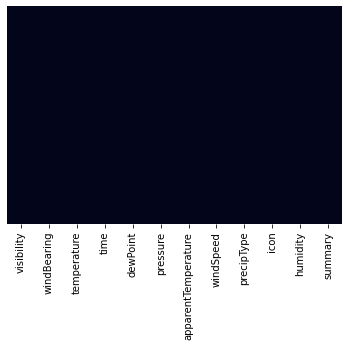

In [5]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False)

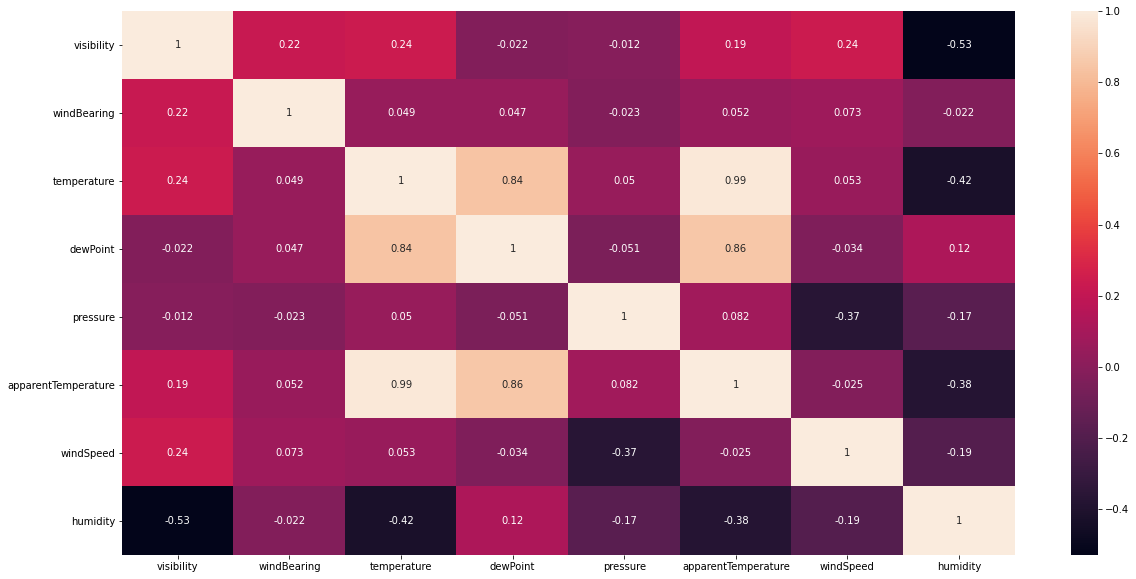

In [6]:
plt.figure(figsize=(20, 10))
p = sns.heatmap(df.corr(), annot=True)

In [7]:
df['Date'] = pd.to_datetime(df['time'])
df['Year'] = df['Date'].dt.year

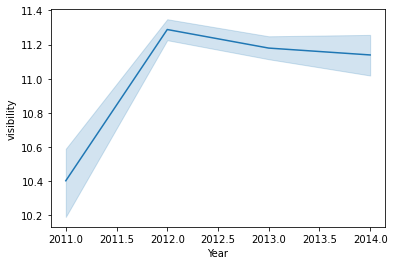

In [8]:
p = sns.lineplot(x="Year", y="visibility", data=df)
_ = plt.ylabel("visibility")

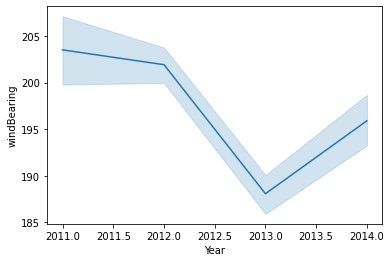

In [9]:
p = sns.lineplot(x="Year", y="windBearing", data=df)
_ = plt.ylabel("windBearing")

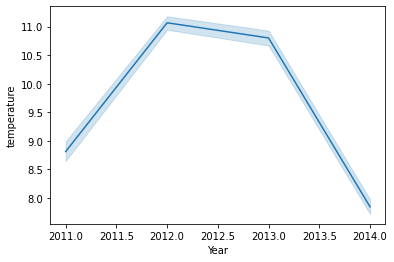

In [10]:
p = sns.lineplot(x="Year", y="temperature", data=df)
_ = plt.ylabel("temperature")

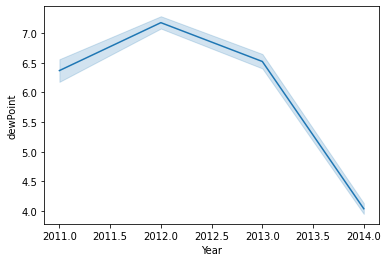

In [11]:
p = sns.lineplot(x="Year", y="dewPoint", data=df)
_ = plt.ylabel("dewPoint")

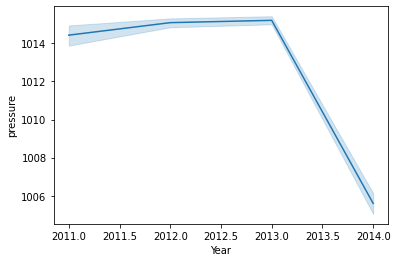

In [12]:
p = sns.lineplot(x="Year", y="pressure", data=df)
_ = plt.ylabel("pressure")

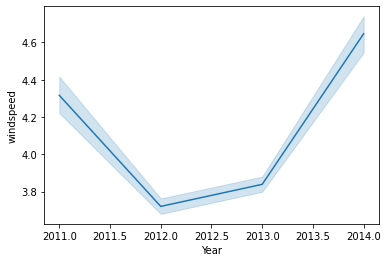

In [13]:
p = sns.lineplot(x="Year", y="windSpeed", data=df)
_ = plt.ylabel("windspeed")

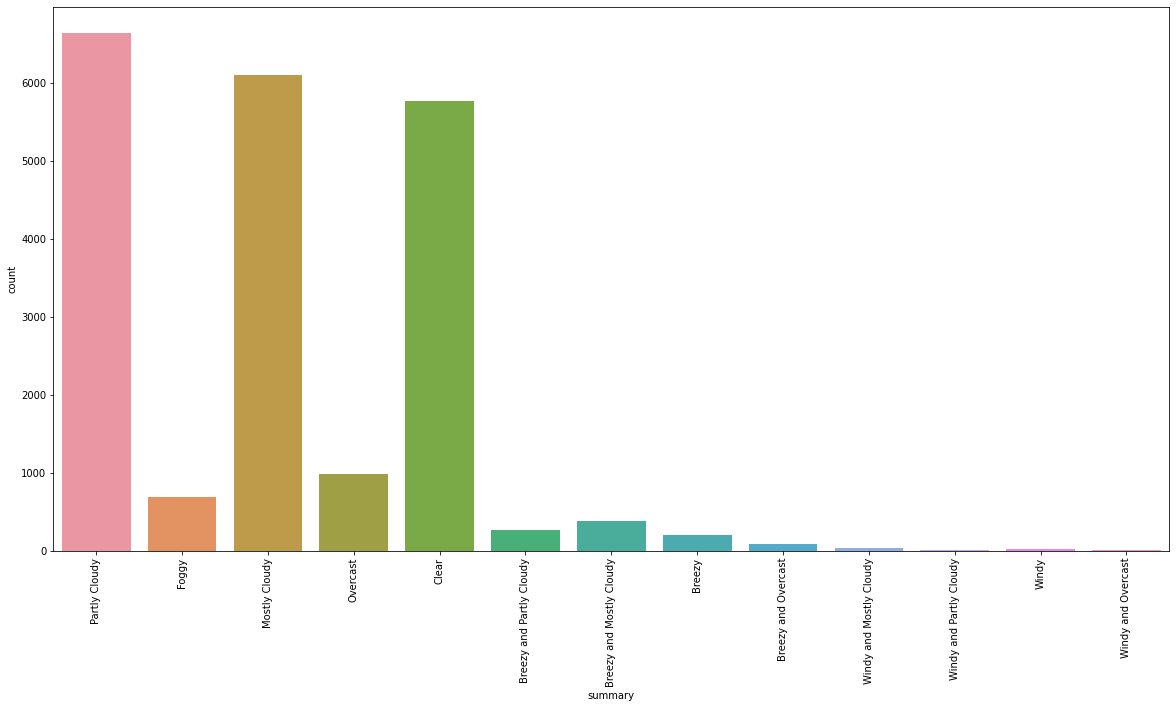

In [14]:
plt.figure(figsize=(20, 10))
p = sns.countplot(x='summary', data=df)
_ = plt.setp(p.get_xticklabels(), rotation=90)

In [15]:
df.head()

,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary,Date,Year
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy,2011-11-11 00:00:00,2011
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy,2011-11-11 01:00:00,2011
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy,2011-11-11 02:00:00,2011
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy,2011-11-11 03:00:00,2011
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy,2011-11-11 04:00:00,2011


In [16]:
df = df.drop(['summary','Date','time'],axis=1)

In [17]:
df = pd.get_dummies(df,drop_first=True)

In [18]:
df.head()

,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,humidity,Year,precipType_snow,icon_clear-night,icon_cloudy,icon_fog,icon_partly-cloudy-day,icon_partly-cloudy-night,icon_wind
0,5.97,104,10.24,8.86,1016.76,10.24,2.77,0.91,2011,0,0,0,0,0,1,0
1,4.88,99,9.76,8.83,1016.63,8.24,2.95,0.94,2011,0,0,0,0,0,1,0
2,3.70,98,9.46,8.79,1016.36,7.76,3.17,0.96,2011,0,0,0,0,0,1,0
3,3.12,99,9.23,8.63,1016.28,7.44,3.25,0.96,2011,0,0,0,1,0,0,0
4,1.85,111,9.26,9.21,1015.98,7.24,3.70,1.00,2011,0,0,0,1,0,0,0


In [19]:
X = df.drop(['windSpeed'],axis=1)
X

,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,humidity,Year,precipType_snow,icon_clear-night,icon_cloudy,icon_fog,icon_partly-cloudy-day,icon_partly-cloudy-night,icon_wind
0,5.97,104,10.24,8.86,1016.76,10.24,0.91,2011,0,0,0,0,0,1,0
1,4.88,99,9.76,8.83,1016.63,8.24,0.94,2011,0,0,0,0,0,1,0
2,3.70,98,9.46,8.79,1016.36,7.76,0.96,2011,0,0,0,0,0,1,0
3,3.12,99,9.23,8.63,1016.28,7.44,0.96,2011,0,0,0,1,0,0,0
4,1.85,111,9.26,9.21,1015.98,7.24,1.00,2011,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21160,12.68,247,7.39,3.06,997.07,3.91,0.74,2014,0,0,0,0,0,1,0
21161,13.78,249,6.56,2.76,998.15,3.03,0.77,2014,0,1,0,0,0,0,0
21162,14.31,248,6.47,2.71,999.28,3.06,0.77,2014,0,1,0,0,0,0,0
21163,14.31,248,5.96,2.69,1000.33,2.68,0.80,2014,0,1,0,0,0,0,0


In [20]:
y = df['windSpeed']
y

0        2.77
1        2.95
2        3.17
3        3.25
4        3.70
         ... 
21160    6.08
21161    5.61
21162    5.25
21163    4.69
21164    5.09
Name: windSpeed, Length: 21165, dtype: float64

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

X_scaled  = preprocessing.scale(X) 
poly = PolynomialFeatures(1) 
y_scale = preprocessing.scale(y)
X_final = poly.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_final, y_scale, test_size=0.2, random_state=42) 

In [31]:
from sklearn import linear_model

regr = linear_model.Ridge(alpha = 0.5) 
regr.fit(X_train, y_train)

y_pred = regr.predict(X_test)
y_pred

array([-0.3812695 , -1.61887454,  0.16071176, ...,  0.96200468,
       -0.69087187, -1.17770333])

In [32]:
from sklearn.metrics import mean_squared_error, r2_score

# Display Model Intercept
print("Intercept: ", regr.intercept_)

# Display Model coefficients
print('Coefficients: \n', len(regr.coef_ ))


print('Mean squared error: %.3f' % mean_squared_error(y_test,  y_pred))


# r2_score (Coefficient of determination) is a great evaluation metric - read more below
print('Coefficient of determination: %.3f' % r2_score(y_test, y_pred))

Intercept:  0.002421309865088141
Coefficients: 
 16
Mean squared error: 0.450
Coefficient of determination: 0.560


In [33]:
import pickle
with open('Weather_Wind_prediction','wb') as f:
    pickle.dump(regr,f)

In [34]:
# Input the attribute of X table  
weatherObs = [[5.97, 104, 8.86, 1016.76, 10.24, 2.77,0.91,2011,0,0,0,0,0,1,0]]

# Apply the same preprocessing steps
weatherObs_scaled = preprocessing.scale(weatherObs) 
weatherObs_final = poly.fit_transform(weatherObs_scaled)

# Use our model to make a prediction for Humidity
y_pred = regr.predict(weatherObs_final)
y_pred

array([0.00242131])